In [ ]:
# Código para entrenamiento de CNN
# ============================================================
# 1. CONEXIÓN A GOOGLE DRIVE E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

"""
En esta sección se conecta Google Drive para acceder al dataset
almacenado en la carpeta del proyecto. Además, se importan las
librerías necesarias para:

- cargar imágenes,
- construir datasets de TensorFlow,
- entrenar el modelo,
- calcular métricas,
- visualizar resultados.
"""

from google.colab import drive
drive.mount('/content/drive')

import time
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# EfficientNetB0 - Modelo de transfer learning elegido
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras import layers, models

Mounted at /content/drive


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# ============================================================
# 2. DEFINICIÓN DE RUTA Y PARÁMETROS GENERALES
# ============================================================

"""
Para este avance se trabajará únicamente con la carpeta train,
debido a que contiene la mayor cantidad de imágenes disponibles, posee
1341 imágenes para clase NORMAL y 3875 imágenes para PNEUMONÍA

A partir de esta carpeta se realizará una nueva división interna:
- entrenamiento
- validación

La división será estratificada para conservar la proporción entre
las clases NORMAL y PNEUMONIA.
"""

BASE = Path('/content/drive/MyDrive/proyecto_patrones_MIV/XRAY')

TRAIN_ORIGINAL_DIR = BASE / 'train'

IMG_SIZE = (224, 224) # Redimensionamiento de 224 x 224
BATCH_SIZE = 32 # Batch predeterminado
SEED = 42 # Semilla que controla la aleatoriedad

print("Ruta train existe:", TRAIN_ORIGINAL_DIR.exists())

# Para ver si existe GPU
tf.config.list_physical_devices('GPU')

Ruta train existe: True


[]

In [ ]:
# ============================================================
# 3. VERIFICACIÓN DE IMÁGENES EN TRAIN
# ============================================================

"""
Se verifica la cantidad de imágenes disponibles en la carpeta train
para cada clase. Esta información permite identificar el tamaño real
del conjunto de trabajo y evaluar si existe desbalance entre clases.
"""

CLASES = ['NORMAL', 'PNEUMONIA']

image_paths = []
labels = []

for idx, clase in enumerate(CLASES):
    carpeta = TRAIN_ORIGINAL_DIR / clase
    archivos = list(carpeta.glob('*'))

    print(f"{clase}: {len(archivos)} imágenes")

    for archivo in archivos:
        image_paths.append(str(archivo))
        labels.append(idx)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("\nTotal de imágenes usadas:", len(image_paths))
print("0 = NORMAL")
print("1 = PNEUMONIA")
print("Ruta = image_paths shape:", image_paths.shape)
print("Etiquetas = labels shape:", labels.shape)

NORMAL: 1341 imágenes
PNEUMONIA: 3875 imágenes

Total de imágenes usadas: 5216
0 = NORMAL
1 = PNEUMONIA
Ruta = image_paths shape: (5216,)
Etiquetas = labels shape: (5216,)


In [ ]:
# ============================================================
# 4. DIVISIÓN ESTRATIFICADA TRAIN / VALIDATION
# ============================================================

"""
A partir de la carpeta train original se crea una división interna
para entrenamiento y validación.

Se utiliza una división estratificada 80/20:
- 80% para entrenamiento
- 20% para validación

Esto permite validar el modelo con una cantidad suficiente de imágenes
y mantener una proporción similar de clases en ambos subconjuntos.
"""

from sklearn.model_selection import train_test_split
from collections import Counter

# Asegurar formato de arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.20, # Validación de 20%
    stratify=labels, # División estratificada
    random_state=SEED
)

print("Entrenamiento:", len(X_train), Counter(y_train))
print("Validación:", len(X_val), Counter(y_val))
print("\nEl conjunto test se mantiene reservado para la evaluación final.")

Entrenamiento: 4172 Counter({np.int64(1): 3099, np.int64(0): 1073})
Validación: 1044 Counter({np.int64(1): 776, np.int64(0): 268})

El conjunto test se mantiene reservado para la evaluación final.


In [ ]:
# ============================================================
# 5. MANEJO DEL DESBALANCE DE CLASES
# ============================================================

"""
Se calculan pesos de clase para compensar el desbalance entre NORMAL y PNEUMONIA.
La clase con menor cantidad de imágenes recibe mayor peso durante el entrenamiento, así se puede evitar
que el modelo favorezca a la clase mayoritaria.
"""

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced', # Balanceado, considerando la proporción de las clases
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: float(class_weights_array[0]),  # NORMAL
    1: float(class_weights_array[1])   # PNEUMONIA
}

print("Pesos de clase:")
print("NORMAL:", class_weights[0])
print("PNEUMONIA:", class_weights[1])

Pesos de clase:
NORMAL: 1.9440820130475303
PNEUMONIA: 0.6731203614069055


In [ ]:
# ============================================================
# 6. CREACIÓN DE DATASETS CON TENSORFLOW
# ============================================================

"""
En esta sección se convierten las rutas de imágenes y sus etiquetas
en datasets de TensorFlow.

Esto permitirá alimentar el modelo CNN en lotes de imágenes durante
el entrenamiento y la validación.
"""

AUTOTUNE = tf.data.AUTOTUNE # Uso de mejor cantidad de datos

def cargar_imagen(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    # En este caso, es necesario usar 3 canales por compatibilidad
    img = tf.image.resize(img, IMG_SIZE) # Resize de 224 x 224
    img = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.float32)
    return img, label



train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

# Procesamiento de cada imagen, pasa a tener imágenes procesadas
train_ds = train_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)

# Mezcla de dataset en entrenamiento
train_ds = train_ds.shuffle(
    buffer_size=len(X_train),
    seed=SEED
)

# Creación de los batches en train
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
# En validación
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Dataset de entrenamiento creado correctamente")
print("Dataset de validación creado correctamente")

Dataset de entrenamiento creado correctamente
Dataset de validación creado correctamente


In [ ]:
# ============================================================
# 7. DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03), # +-10.8 grados
    tf.keras.layers.RandomZoom(0.10), # Zoom aleatorio de un 10%
    tf.keras.layers.RandomTranslation(0.05, 0.05), # Movimiento aleatorio de un 5%
], name="data_augmentation")

print("Data augmentation definido correctamente")

Data augmentation definido correctamente


In [ ]:
# ============================================================
# 8. Modelo ligero con Transfer Learning
# ============================================================

def construir_modelo_efficientnetb0():
    input_shape = (224, 224, 3)

    # Base convolucional EfficientNetB0 preentrenada
    base_model = EfficientNetB0(
        weights="imagenet",  # Pesos preentrenados de ImageNet
        include_top=False, # Quito la cabeza original de ImageNet para la clasificación propia
        input_shape=input_shape # Input ya elegido
    )

    # Congelar la base al inicio
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs) # DataAugmentation
    x = layers.Lambda(efficientnet_preprocess)(x) # Normalización (no es necesaria)
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Salida final del modelo, sigmoid usa un valor entre 0 y 1
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="EfficientNetB0_transfer")

    return model, base_model


modelo_efficientnetb0, base_model = construir_modelo_efficientnetb0()

modelo_efficientnetb0.summary()


Model: "EfficientNetB0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# ============================================================
# 9. CARPETA DE RESULTADOS
# ============================================================

RESULTS_DIR = BASE / f"resultados_EficcientNetB0_batch32__modelo_final"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Resultados se guardarán en:", RESULTS_DIR)

Resultados se guardarán en: /content/drive/MyDrive/proyecto_patrones_MIV/XRAY/resultados_EficcientNetB0_batch32__modelo_final


In [ ]:
# ============================================================
# 10. COMPILACIÓN DEL MODELO - ETAPA 1: BASE CONGELADA
# ============================================================

"""
En esta primera etapa se entrena únicamente la cabeza clasificadora
agregada sobre ImageNetB0.
"""

modelo_efficientnetb0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        str(RESULTS_DIR / f"modelo_EfficientNetB0_frozen.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=2,
        mode="max",
        min_lr=1e-6
    )
]

In [ ]:
# ============================================================
# 11. ENTRENAMIENTO PRELIMINAR DEL MODELO BASELINE
# ============================================================

inicio_frozen = time.time()

history_frozen = modelo_efficientnetb0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

fin_frozen = time.time()

tiempo_frozen = fin_frozen - inicio_frozen

print(f"Tiempo de entrenamiento preliminar: {tiempo_frozen/60:.2f} minutos")

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.8543 - auc: 0.9409 - loss: 0.3241 - precision: 0.9611 - recall: 0.8377 - val_accuracy: 0.9416 - val_auc: 0.9846 - val_loss: 0.2157 - val_precision: 0.9649 - val_recall: 0.9562 - learning_rate: 3.0000e-04
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.9156 - auc: 0.9746 - loss: 0.2073 - precision: 0.9738 - recall: 0.9109 - val_accuracy: 0.9090 - val_auc: 0.9864 - val_loss: 0.2201 - val_precision: 0.9913 - val_recall: 0.8853 - learning_rate: 3.0000e-04
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step - accuracy: 0.9175 - auc: 0.9749 - loss: 0.2059 - precision: 0.9755 - recall: 0.9119 - val_accuracy: 0.9109 - val_auc: 0.9885 - val_loss: 0.2027 - val_precision: 0.9914 - val_recall: 0.8879 - learning_rate: 3.0000e-04
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9226 - auc: 0.9791 - loss: 0.1869 - precision: 0.9750 - recall: 0.9193 - val_accuracy: 0.9272 - val_auc: 0.9907 - val_lo

In [ ]:
# ============================================================
# 12. FINE-TUNING DE DENSENET121
# ============================================================

"""
Se descongelan únicamente las capas finales del último bloque denso
de DenseNet121, mientras que las capas iniciales permanecen congeladas.

Esto permite adaptar mejor el modelo al dominio de radiografías
de tórax sin incrementar demasiado el costo computacional.
"""

base_model.trainable = True

# Congelar todo primero
for layer in base_model.layers:
    layer.trainable = False

# Descongelar solo las últimas N capas
N_CAPAS_FINE_TUNING = 40

for layer in base_model.layers[-N_CAPAS_FINE_TUNING:]:
    # Mantener BatchNorm congeladas suele ser más estable en transfer learning
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
total_count = len(base_model.layers)

print("Capas entrenables en base_model:", trainable_count)
print("Capas totales en base_model:", total_count)

modelo_efficientnetb0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        str(RESULTS_DIR / f"modelo_MobileNetB0_finetuned.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=2,
        mode="max",
        min_lr=1e-7
    )
]


inicio_finetune = time.time()

# Entrenamiento de fine-tuning con el nuevo modelo
history_finetune =modelo_efficientnetb0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

fin_finetune = time.time()
tiempo_finetune = fin_finetune - inicio_finetune
print(f"Tiempo de entrenamiento fine-tuning: {tiempo_finetune/60:.2f} minutos")

Capas entrenables en base_model: 32
Capas totales en base_model: 238
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.9413 - auc: 0.9864 - loss: 0.1472 - precision: 0.9811 - recall: 0.9390 - val_accuracy: 0.9444 - val_auc: 0.9951 - val_loss: 0.1361 - val_precision: 0.9972 - val_recall: 0.9278 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9420 - auc: 0.9873 - loss: 0.1383 - precision: 0.9834 - recall: 0.9377 - val_accuracy: 0.9377 - val_auc: 0.9955 - val_loss: 0.1516 - val_precision: 0.9972 - val_recall: 0.9188 - learning_rate: 1.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9434 - auc: 0.9888 - loss: 0.1320 - precision: 0.9831 - recall: 0.9400 - val_accuracy: 0.9454 - val_auc: 0.9958 - val_loss: 0.1262 - val_precision: 0.9972 - val_recall: 0.9291 - learning_rate: 1.0000e-05
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9453 - auc: 0.9894 - loss: 0.1271 - precision: 0.98

In [ ]:
# Guardado del modelo final
modelo_efficientnetb0.save(RESULTS_DIR / f"modelo_EfficientNetB0_final.keras")

# Tiempo total de la computación
tiempo_total = tiempo_frozen + tiempo_finetune
print(f"Tiempo total de entrenamiento: {tiempo_total/60:.2f} minutos")

Tiempo total de entrenamiento: 133.69 minutos


In [ ]:
# ============================================================
# 13. EVALUACIÓN DEL MODELO EN VALIDACIÓN
# ============================================================

val_loss, val_acc, val_auc, val_precision, val_recall = modelo_efficientnetb0.evaluate(val_ds)

print("Resultados en validación:")
print("Loss:", val_loss)
print("Accuracy:", val_acc)
print("AUC:", val_auc)
print("Precision:", val_precision)
print("Recall/Sensibilidad:", val_recall)

33/33 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9598 - auc: 0.9966 - loss: 0.0947 - precision: 0.9946 - recall: 0.9510
Resultados en validación:
Loss: 0.09468695521354675
Accuracy: 0.959770143032074
AUC: 0.9966076612472534
Precision: 0.9946091771125793
Recall/Sensibilidad: 0.9510309100151062


In [ ]:
# ============================================================
# 14. MATRIZ DE CONFUSIÓN Y MÉTRICAS
# ============================================================

y_true = []
y_prob = []

for images, labels_batch in val_ds:
    probs = modelo_efficientnetb0.predict(images, verbose=0)
    y_prob.extend(probs.ravel())
    y_true.extend(labels_batch.numpy())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

FINAL_THRESHOLD = 0.5
threshold = FINAL_THRESHOLD

y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)  # sensibilidad para PNEUMONIA
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Matriz de confusión:")
print(cm)

print("\nMétricas de validación:")
print("Accuracy:", accuracy)
print("Sensibilidad / Recall PNEUMONIA:", sensitivity)
print("Especificidad / Recall NORMAL:", specificity)
print("Precision:", precision)
print("F1-score:", f1)
print("AUC-ROC:", auc_score)

print("\nReporte de clasificación:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

Matriz de confusión:
[[264   4]
 [ 38 738]]

Métricas de validación:
Accuracy: 0.9597701149425287
Sensibilidad / Recall PNEUMONIA: 0.9510309278350515
Especificidad / Recall NORMAL: 0.9850746268656716
Precision: 0.9946091644204852
F1-score: 0.9723320158102767
AUC-ROC: 0.9966437144176027

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       0.87      0.99      0.93       268
   PNEUMONIA       0.99      0.95      0.97       776

    accuracy                           0.96      1044
   macro avg       0.93      0.97      0.95      1044
weighted avg       0.96      0.96      0.96      1044



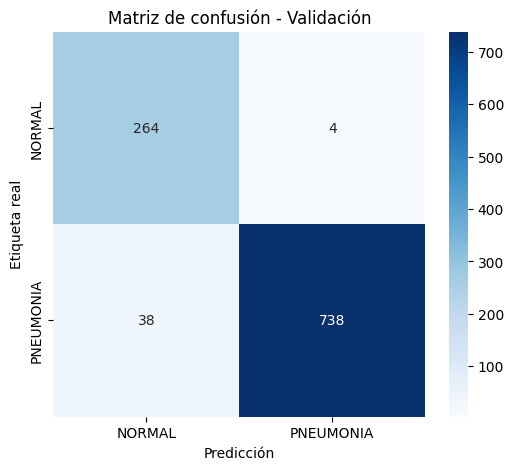

In [ ]:
# ============================================================
# 15. VISUALIZACIÓN DE MATRIZ DE CONFUSIÓN
# ============================================================

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - Validación")
plt.savefig(RESULTS_DIR / "matriz_confusion_validacion.png", dpi=300, bbox_inches="tight")
plt.show()

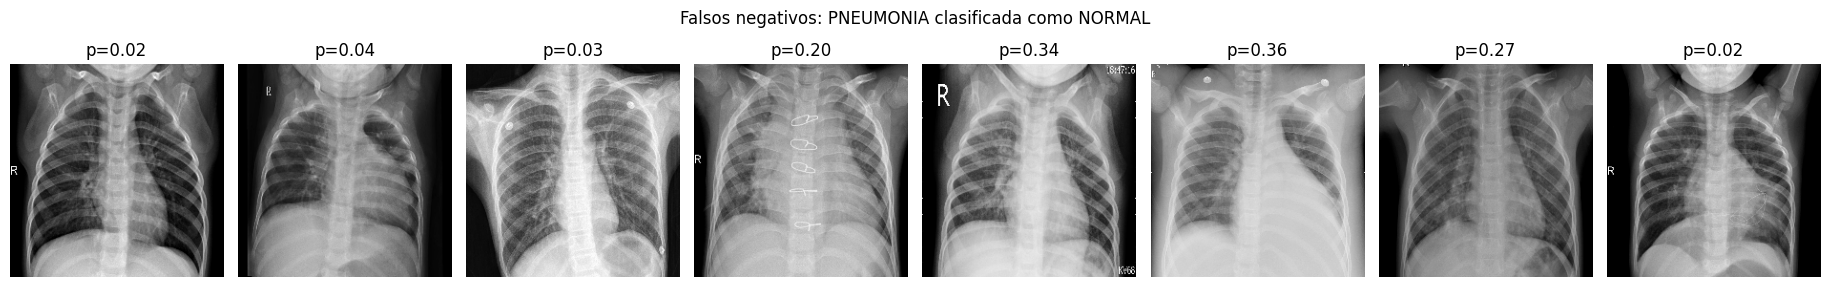

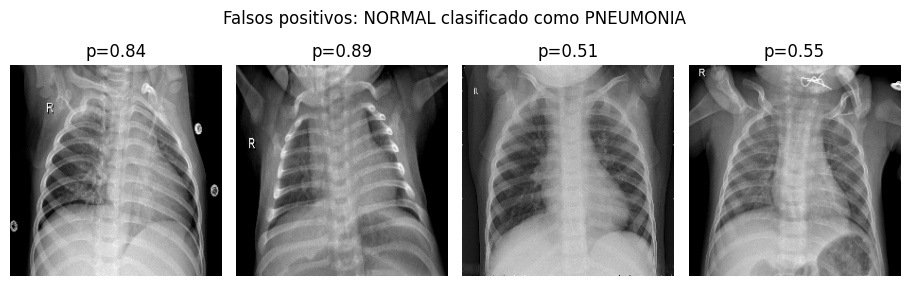

In [ ]:
# ============================================================
# 16. VISUALIZACIÓN DE FALSOS NEGATIVOS Y FALSOS POSITIVOS
# ============================================================

def mostrar_errores_imagenes(paths, y_true, y_prob, threshold=FINAL_THRESHOLD, error_type="FN", max_images=8):
    """
    Visualiza imágenes mal clasificadas:
    FN: PNEUMONIA real clasificada como NORMAL
    FP: NORMAL real clasificada como PNEUMONIA
    """

    y_pred = (y_prob >= threshold).astype(int)

    if error_type == "FN":
        idxs = np.where((y_true == 1) & (y_pred == 0))[0]
        titulo = "Falsos negativos: PNEUMONIA clasificada como NORMAL"

    elif error_type == "FP":
        idxs = np.where((y_true == 0) & (y_pred == 1))[0]
        titulo = "Falsos positivos: NORMAL clasificado como PNEUMONIA"

    else:
        raise ValueError("error_type debe ser 'FN' o 'FP'")

    if len(idxs) == 0:
        print(f"No se encontraron errores tipo {error_type} con threshold={threshold}.")
        return

    chosen = idxs[:max_images]

    fig, axes = plt.subplots(1, len(chosen), figsize=(2.3 * len(chosen), 3))

    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        img = tf.io.read_file(str(paths[idx]))
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = img.numpy().astype("uint8")

        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(f"p={y_prob[idx]:.2f}")

    plt.suptitle(titulo)
    plt.tight_layout()

    nombre_archivo = f"{error_type}_threshold_{threshold}.png"
    plt.savefig(RESULTS_DIR / nombre_archivo, dpi=300, bbox_inches="tight")

    plt.show()

mostrar_errores_imagenes(
    X_val,
    y_true,
    y_prob,
    threshold=FINAL_THRESHOLD,
    error_type="FN",
    max_images=8
)

mostrar_errores_imagenes(
    X_val,
    y_true,
    y_prob,
    threshold=FINAL_THRESHOLD,
    error_type="FP",
    max_images=8
)

In [ ]:
# ============================================================
# 16.2 TABLA DE FALSOS NEGATIVOS Y FALSOS POSITIVOS
# ============================================================

errores_df = pd.DataFrame({
    "path": X_val,
    "y_true": y_true,
    "y_prob_pneumonia": y_prob,
    "y_pred": y_pred
})

errores_df["clase_real"] = errores_df["y_true"].map({
    0: "NORMAL",
    1: "PNEUMONIA"
})

errores_df["clase_predicha"] = errores_df["y_pred"].map({
    0: "NORMAL",
    1: "PNEUMONIA"
})

falsos_negativos = errores_df[
    (errores_df["y_true"] == 1) & (errores_df["y_pred"] == 0)
]

falsos_positivos = errores_df[
    (errores_df["y_true"] == 0) & (errores_df["y_pred"] == 1)
]

print("Cantidad de falsos negativos:", len(falsos_negativos))
display(falsos_negativos[["path", "clase_real", "clase_predicha", "y_prob_pneumonia"]])

print("Cantidad de falsos positivos:", len(falsos_positivos))
display(falsos_positivos[["path", "clase_real", "clase_predicha", "y_prob_pneumonia"]])

Cantidad de falsos negativos: 38


,path,clase_real,clase_predicha,y_prob_pneumonia
9,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.020472
23,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.042013
36,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.026113
75,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.198441
79,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.340749
91,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.361002
120,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.271226
131,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.019389
138,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.383180
146,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.399946


Cantidad de falsos positivos: 4


,path,clase_real,clase_predicha,y_prob_pneumonia
195,/content/drive/MyDrive/proyecto_patrones_MIV/X...,NORMAL,PNEUMONIA,0.837476
309,/content/drive/MyDrive/proyecto_patrones_MIV/X...,NORMAL,PNEUMONIA,0.893211
422,/content/drive/MyDrive/proyecto_patrones_MIV/X...,NORMAL,PNEUMONIA,0.505258
479,/content/drive/MyDrive/proyecto_patrones_MIV/X...,NORMAL,PNEUMONIA,0.545096


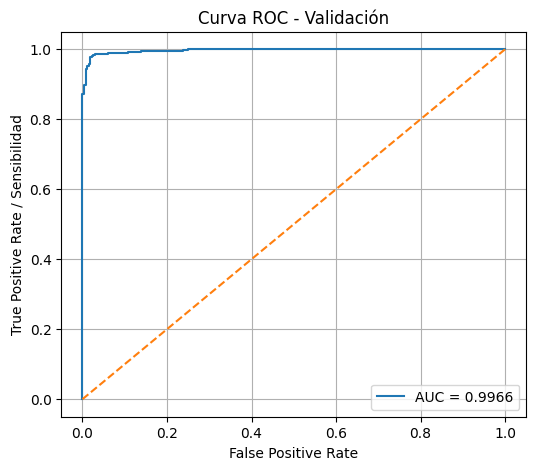

In [ ]:
# ============================================================
# 17. CURVA ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensibilidad")
plt.title("Curva ROC - Validación")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_roc_validacion.png", dpi=300, bbox_inches="tight")
plt.show()

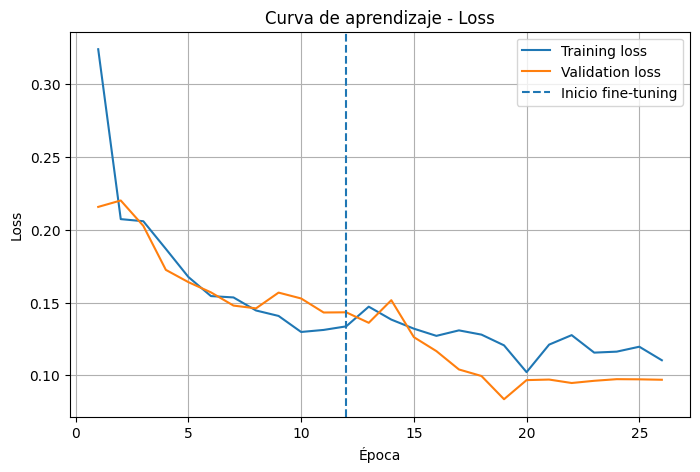

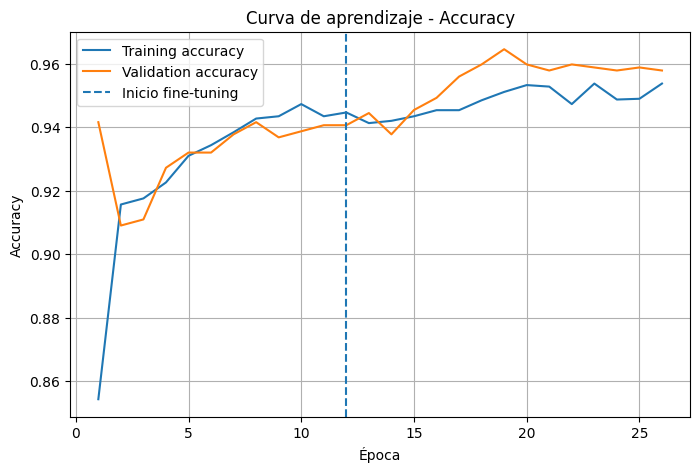

In [ ]:
# ============================================================
# 18. CURVAS DE APRENDIZAJE: LOSS Y ACCURACY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Unir historial de etapa congelada + fine-tuning
loss = history_frozen.history["loss"] + history_finetune.history["loss"]
val_loss = history_frozen.history["val_loss"] + history_finetune.history["val_loss"]

accuracy = history_frozen.history["accuracy"] + history_finetune.history["accuracy"]
val_accuracy = history_frozen.history["val_accuracy"] + history_finetune.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

# ----------------------------
# Curva de Loss
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.axvline(x=len(history_frozen.history["loss"]), linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje - Loss")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_loss.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Curva de Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.axvline(x=len(history_frozen.history["accuracy"]), linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje - Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

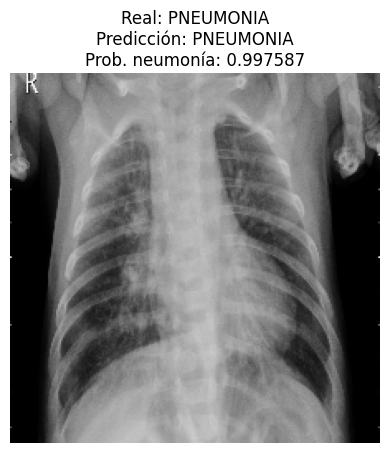

In [ ]:
CLASES = ["NORMAL", "PNEUMONIA"]
FINAL_THRESHOLD = 0.50
modelo = modelo_efficientnetb0  # o modelo_efficientnetb0 si no lo cargaste desde .keras

# Tomar un batch de validación
imgs, labels = next(iter(val_ds))

probs = modelo.predict(imgs, verbose=0).ravel()
preds = (probs >= FINAL_THRESHOLD).astype(int)
labels_np = labels.numpy().astype(int)

# Índices correctamente clasificados
correctos = np.where(preds == labels_np)[0]

# Elegir uno aleatorio
i = np.random.choice(correctos)

img = imgs[i].numpy()
if img.max() > 1:
    img = img / 255.0

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Real: {CLASES[labels_np[i]]}\n"
    f"Predicción: {CLASES[preds[i]]}\n"
    f"Prob. neumonía: {probs[i]:.6f}"
)
plt.show()